In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.metrics import ConfusionMatrixDisplay

In [3]:
red = pd.read_csv(r"C:\Users\shafaat hussain\Desktop\aiml\wine\winequality-red.csv")    # Update paths if needed
white = pd.read_csv(r"C:\Users\shafaat hussain\Desktop\aiml\wine\winequality-white.csv")
red['type'] = 0
white['type'] = 1

df = pd.concat([red, white], ignore_index=True)
print("Combined Shape:", df.shape)
print("Quality Distribution:\n", df['quality'].value_counts(normalize=True))

Combined Shape: (6497, 13)
Quality Distribution:
 quality
6    0.436509
5    0.329075
7    0.166077
4    0.033246
8    0.029706
3    0.004618
9    0.000770
Name: proportion, dtype: float64


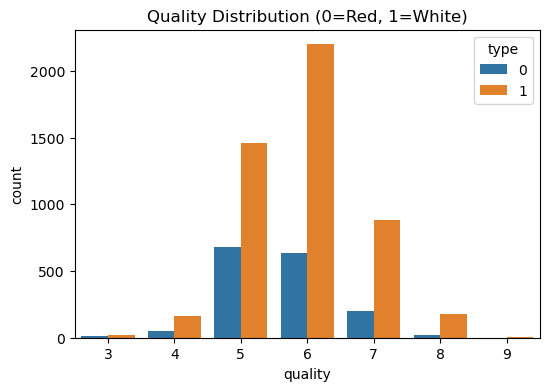

In [4]:
plt.figure(figsize=(6,4))
sns.countplot(x='quality', data=df, hue='type')
plt.title('Quality Distribution (0=Red, 1=White)')
plt.show()

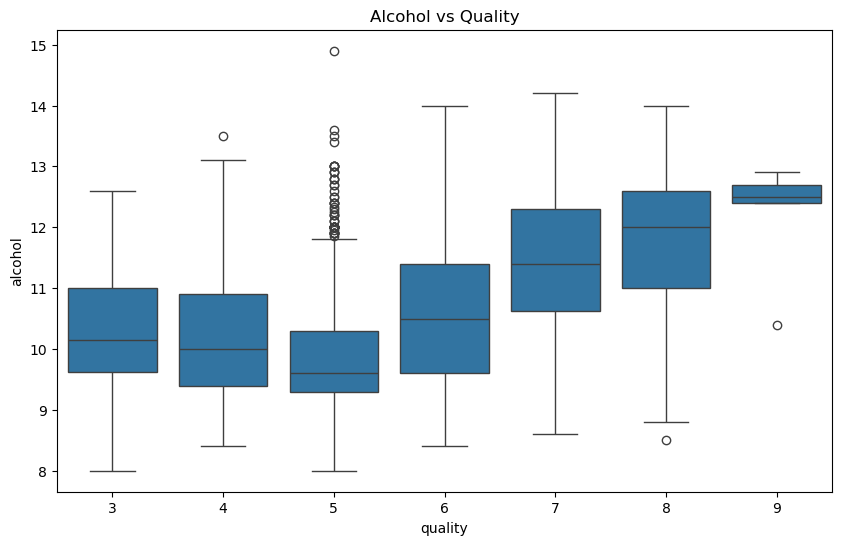

In [5]:
plt.figure(figsize=(10,6))
sns.boxplot(x='quality', y='alcohol', data=df)
plt.title('Alcohol vs Quality')
plt.show()

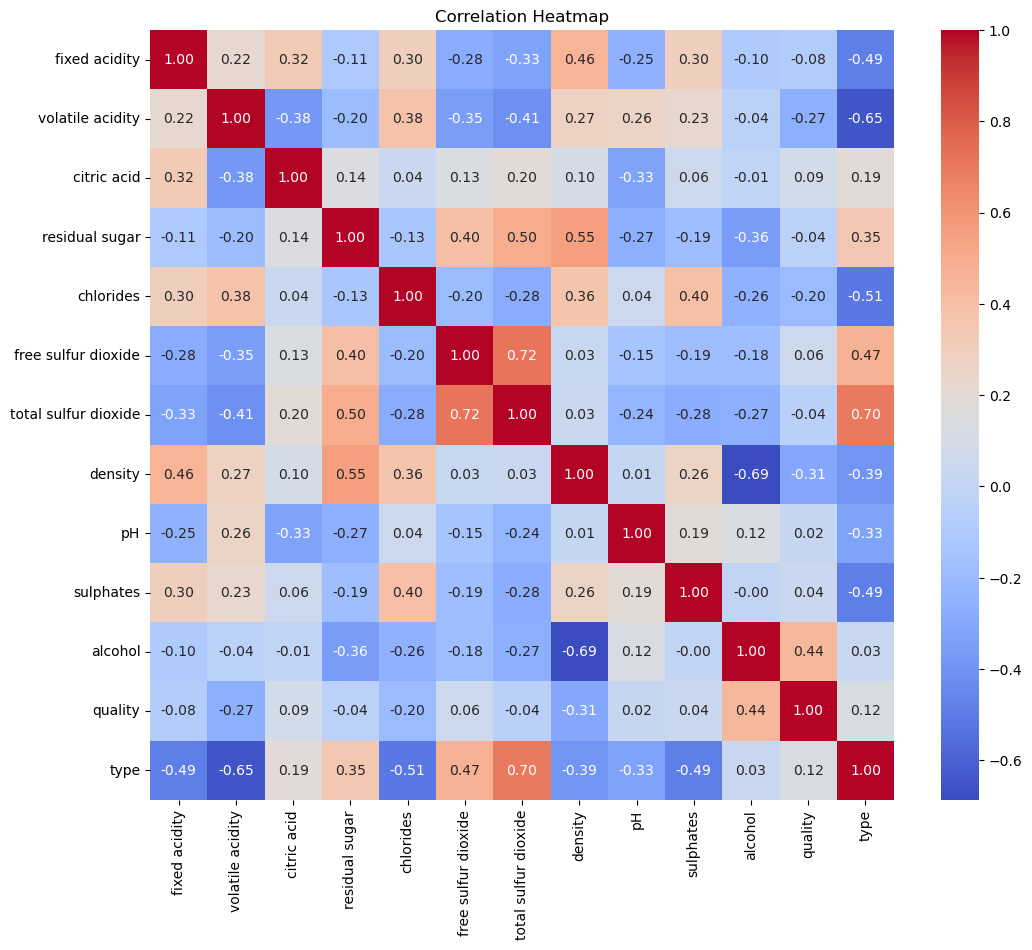

In [6]:
numeric_df = df.select_dtypes(include=['float64', 'int64'])
corr = numeric_df.corr()
plt.figure(figsize=(12,10))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

In [7]:
X = df.drop('quality', axis=1)
y = df['quality']

numeric_features = X.columns.drop('type').tolist()
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', 'passthrough', ['type'])  # Keep type as is (binary)
    ]
)

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

C:\Users\shafaat hussain\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



Logistic Regression Report:
               precision    recall  f1-score   support

           3       0.02      0.50      0.04         6
           4       0.11      0.42      0.17        43
           5       0.57      0.39      0.46       428
           6       0.57      0.25      0.35       567
           7       0.31      0.28      0.30       216
           8       0.08      0.46      0.13        39
           9       0.00      0.00      0.00         1

    accuracy                           0.32      1300
   macro avg       0.24      0.33      0.21      1300
weighted avg       0.49      0.32      0.36      1300



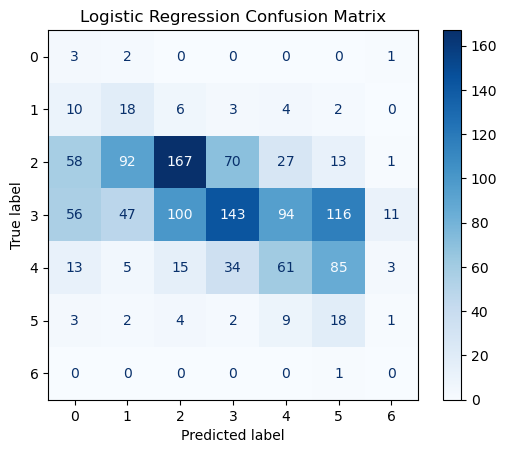


Decision Tree Report:
               precision    recall  f1-score   support

           3       0.00      0.00      0.00         6
           4       0.21      0.19      0.20        43
           5       0.63      0.66      0.64       428
           6       0.65      0.61      0.63       567
           7       0.53      0.59      0.56       216
           8       0.40      0.41      0.41        39
           9       0.00      0.00      0.00         1

    accuracy                           0.60      1300
   macro avg       0.35      0.35      0.35      1300
weighted avg       0.60      0.60      0.60      1300



C:\Users\shafaat hussain\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\shafaat hussain\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\shafaat hussain\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


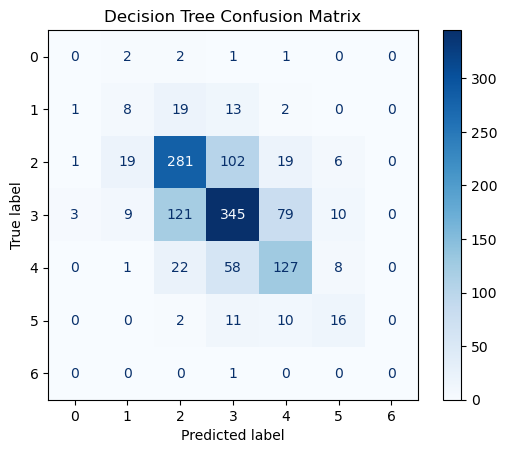


Random Forest Report:
               precision    recall  f1-score   support

           3       0.00      0.00      0.00         6
           4       0.57      0.09      0.16        43
           5       0.74      0.70      0.72       428
           6       0.65      0.81      0.72       567
           7       0.70      0.56      0.62       216
           8       1.00      0.33      0.50        39
           9       0.00      0.00      0.00         1

    accuracy                           0.69      1300
   macro avg       0.52      0.36      0.39      1300
weighted avg       0.69      0.69      0.67      1300



C:\Users\shafaat hussain\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\shafaat hussain\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\shafaat hussain\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


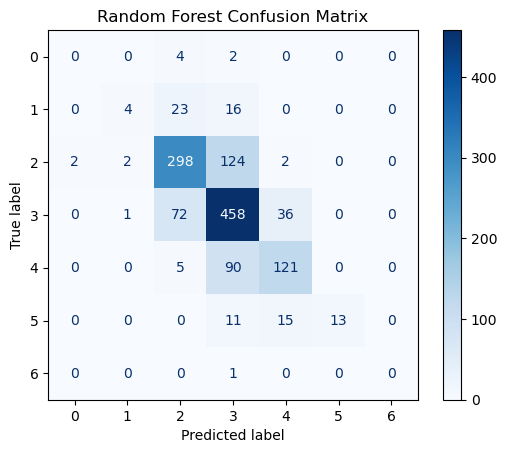

In [9]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', multi_class='multinomial'),
    'Decision Tree': DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
}

results = {}
for name, model in models.items():
    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', model)])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro')
    results[name] = {'Accuracy': acc, 'F1-Macro': f1}
    
    print(f"\n{name} Report:\n", classification_report(y_test, y_pred))
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues')
    plt.title(f'{name} Confusion Matrix')
    plt.show()

In [10]:
results_df = pd.DataFrame(results).T
print("Model Comparison:\n", results_df)

Model Comparison:
                      Accuracy  F1-Macro
Logistic Regression  0.315385  0.207691
Decision Tree        0.597692  0.347194
Random Forest        0.687692  0.388630


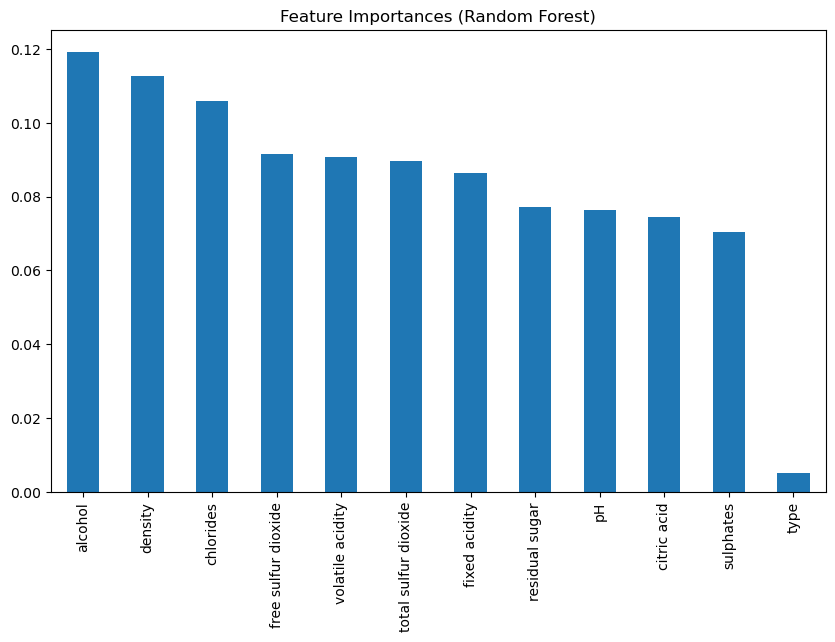

In [11]:
best_model = Pipeline(steps=[('preprocessor', preprocessor), 
                             ('classifier', RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'))])
best_model.fit(X_train, y_train)

feature_names = numeric_features + ['type']

importances = best_model.named_steps['classifier'].feature_importances_
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10,6))
feat_imp.plot(kind='bar')
plt.title('Feature Importances (Random Forest)')
plt.show()

In [12]:
#Example 
new_data = pd.DataFrame({
    'fixed acidity': [7.0], 'volatile acidity': [0.27], 'citric acid': [0.36],
    'residual sugar': [20.7], 'chlorides': [0.045], 'free sulfur dioxide': [45],
    'total sulfur dioxide': [170], 'density': [1.001], 'pH': [3.0],
    'sulphates': [0.45], 'alcohol': [8.8], 'type': [1]  # 1=white
})

pred = best_model.predict(new_data)
print("Predicted Quality:", pred[0])

Predicted Quality: 6
